# Introduction

This is a capstone for my bootcamp program at Flatiron School. My project is to work with electronic music data to create a product that someone can upload there music and the model will classify it into a genre.

This project will take place in multpile notebooks, this one being the first. This notebook is going to be a descriptive and partial inferential anaysis of my data.

# Imports

Let's start with some basic imports,

pandas - used for tabular data manipulation

matplotlib and seaborn - used for data visualization

scipy.stats - used for the partial inferential analysis

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

My data is broken up into a large number of different CSVs so first thing I am going to do is go through each of them and clean them up to the best of my ability

# Artist

This is our first CSV, just from a first glace, I can already tell that i wont need to use the `artist_url` and the `updated_on` columns

In [3]:
bp_artist = pd.read_csv('data/bp_artist.csv')
bp_artist.head()

,artist_id,artist_name,artist_url,updated_on
0,31526,Tromesa,beatport.com/artist/tromesa/31526,2023-09-14 16:19:56
1,943790,Magik (UK),beatport.com/artist/magik-uk/943790,2023-09-14 16:19:56
2,1027936,Abdul Raeva,beatport.com/artist/abdul-raeva/1027936,2023-09-14 16:19:56
3,806738,Gerwin Van Engelenburg,beatport.com/artist/gerwin-van-engelenburg/806738,2023-09-14 16:19:56
4,42053,Angelo D'onorio,beatport.com/artist/angelo-donorio/42053,2023-09-14 16:19:56


In [4]:
bp_artist.drop(['artist_url', 'updated_on'], inplace=True, axis=1)

# Artist Media

At this moment, I don't think I'm going to need to use any of the columns here so im going to leave this dataframe alone for now

In [5]:
bp_artist_media = pd.read_csv('data/bp_artist_media.csv')
bp_artist_media.head()

,artist_id,artist_img_id,artist_img_uuid,updated_on
0,31526,5539565,0dc61986-bccf-49d4-8fad-6b147ea8f327,2023-09-14 16:19:56
1,943790,33043689,eb634b33-3621-4149-bed3-446390730ea6,2023-09-14 16:19:56
2,1027936,5539565,0dc61986-bccf-49d4-8fad-6b147ea8f327,2023-09-14 16:19:56
3,806738,29784707,4b59c9fc-4369-43a3-ab94-90228be91b1c,2023-09-14 16:19:56
4,42053,33151213,d7b33b25-7b21-4a4f-abc1-bdc7e8f0af9f,2023-09-14 16:19:56


# Artist Release

Similar to Artist Media, I dont think any of these columns are relevant to me at this moment so I am just going to leave the entire dataframe alone for now

In [6]:
bp_artist_release = pd.read_csv('data/bp_artist_release.csv')
bp_artist_release.head()

,artist_id,release_id,updated_on
0,31526,4141705,2023-09-14 16:19:56
1,943790,4141705,2023-09-14 16:19:56
2,1027936,4144460,2023-09-14 16:19:56
3,806738,4153005,2023-09-14 16:19:56
4,42053,4153005,2023-09-14 16:19:56


# Artist Track

Not relavent yet, Leaving alone

In [7]:
bp_artist_track = pd.read_csv('data/bp_artist_track.csv')
bp_artist_track.head()

,artist_id,track_id,updated_on,is_remixer
0,31526,17767172,2023-09-14 16:19:56,f
1,943790,17767172,2023-09-14 16:19:56,f
2,1027936,17775434,2023-09-14 16:19:56,f
3,806738,17800962,2023-09-14 16:19:56,f
4,42053,17800962,2023-09-14 16:19:56,t


# Genre

This dataframe is going to be very important as it will be the basis of the majority of the project. for that im going to get rid of the `genre_url` column and the `updated_on` column

In [8]:
bp_genre = pd.read_csv('data/bp_genre.csv')
bp_genre.head()

,genre_id,genre_name,song_count,genre_url,updated_on
0,8,Hard Dance / Hardcore,178646,/genre/hard-dance-hardcore/8,2023-09-19 15:01:03
1,50,Nu Disco / Disco,157934,/genre/nu-disco-disco/50,2023-09-19 15:01:03
2,12,Deep House,897280,/genre/deep-house/12,2023-09-19 15:01:03
3,85,Bass / Club,20716,/genre/bass-club/85,2023-09-19 15:01:03
4,94,Electro (Classic / Detroit / Modern),19615,/genre/electro-classic-detroit-modern/94,2023-09-19 15:01:03


In [9]:
bp_genre.drop(columns=['genre_url', 'updated_on'], inplace=True, axis=1)

Also, I wanted to get a quick look at all the different genres that I'll be working with in my dataset

In [10]:
# Calculate the total number of songs across all genres
total_songs = bp_genre['song_count'].sum()

# Create a new column to calculate the percentage share for each genre
bp_genre['percentage_share'] = (bp_genre['song_count'] / total_songs) * 100

# Sort the dataframe by song_count in descending order
bp_genre_sorted = bp_genre.sort_values(by='song_count', ascending=False)

# Display the sorted dataframe with total and percentage share
bp_genre_sorted[['genre_name', 'song_count', 'percentage_share']]


,genre_name,song_count,percentage_share
17,Electronica,1375001,12.738661
20,House,1214065,11.247674
29,Techno (Peak Time / Driving),1167584,10.817052
26,Tech House,1004359,9.304858
2,Deep House,897280,8.312827
9,Progressive House,579396,5.367799
14,Mainstage,501351,4.644753
22,Dance / Electro Pop,496987,4.604323
28,Trance (Main Floor),479418,4.441556
13,Minimal / Deep Tech,450138,4.170292


In [11]:
bp_key = pd.read_csv('data/bp_key.csv')
bp_key_sorted = bp_key.sort_values(by='key_id', ascending=True)
bp_key_sorted

,key_id,key_letter,key_name,camelot_num,camelot_letter,is_sharp,is_flat,chord_id,chord_name,scale_numeric_value
0,1,A,Ab Minor,1,A,f,t,1,Minor,17
1,2,E,Eb Minor,2,A,f,t,1,Minor,7
2,3,B,Bb Minor,3,A,f,t,1,Minor,21
3,4,F,F Minor,4,A,f,f,1,Minor,11
4,5,C,C Minor,5,A,f,f,1,Minor,1
5,6,G,G Minor,6,A,f,f,1,Minor,15
6,7,D,D Minor,7,A,f,f,1,Minor,5
7,8,A,A Minor,8,A,f,f,1,Minor,19
8,9,E,E Minor,9,A,f,f,1,Minor,9
9,10,B,B Minor,10,A,f,f,1,Minor,23


In [12]:
bp_key

,key_id,key_letter,key_name,camelot_num,camelot_letter,is_sharp,is_flat,chord_id,chord_name,scale_numeric_value
0,1,A,Ab Minor,1,A,f,t,1,Minor,17
1,2,E,Eb Minor,2,A,f,t,1,Minor,7
2,3,B,Bb Minor,3,A,f,t,1,Minor,21
3,4,F,F Minor,4,A,f,f,1,Minor,11
4,5,C,C Minor,5,A,f,f,1,Minor,1
5,6,G,G Minor,6,A,f,f,1,Minor,15
6,7,D,D Minor,7,A,f,f,1,Minor,5
7,8,A,A Minor,8,A,f,f,1,Minor,19
8,9,E,E Minor,9,A,f,f,1,Minor,9
9,10,B,B Minor,10,A,f,f,1,Minor,23


In [13]:
bp_label = pd.read_csv('data/bp_label.csv')
bp_label.head()

,label_id,label_name,label_url,updated_on
0,2527,Nano Records,beatport.com/label/nano-records/2527,2023-09-14 16:19:56
1,3222,Permanent Vacation,beatport.com/label/permanent-vacation/3222,2023-09-14 16:19:56
2,24479,Metrohm,beatport.com/label/metrohm/24479,2023-09-14 16:19:56
3,258,JOOF Recordings,beatport.com/label/joof-recordings/258,2023-09-14 16:19:56
4,68438,IONO BLACK,beatport.com/label/iono-black/68438,2023-09-14 16:19:56


In [14]:
bp_label.drop(columns=['label_url', 'updated_on'], inplace=True, axis=1)

In [15]:
bp_label_media = pd.read_csv('data/bp_label_media.csv')
bp_label_media.head()

,label_id,label_img_id,label_img_uuid,updated_on
0,2527,9457545,160fb48a-dc1b-4e52-a807-d1f49707cd29,2023-09-14 16:19:56
1,3222,10179061,ed8588b3-35a4-4f2e-a7d3-08483e8013db,2023-09-14 16:19:56
2,24479,11928126,06c116df-1d9e-43fc-9c5a-4e4439917311,2023-09-14 16:19:56
3,258,10819653,b641d3e6-c310-4211-924e-11f806f9187b,2023-09-14 16:19:56
4,68438,18629031,9a593521-b921-48d7-8619-8830f1d99ced,2023-09-14 16:19:56


In [16]:
bp_label_media.drop(columns=['updated_on'], inplace=True, axis=1)

In [17]:
bp_release = pd.read_csv('data/bp_release.csv')
bp_release.head()

,release_id,release_title,release_date,release_url,label_id,updated_on
0,4141705,The Land Of Cosmic Speculation,2023-06-09,beatport.com/release/the-land-of-cosmic-specul...,2527,2023-09-14 16:19:56
1,4144460,Permanent Vacation 8,2023-06-09,beatport.com/release/permanent-vacation-8/4144460,3222,2023-09-14 16:19:56
2,4153005,Traveller,2023-06-06,beatport.com/release/traveller/4153005,24479,2023-09-14 16:19:56
3,4091230,Nehorah / Akawi,2023-06-05,beatport.com/release/nehorah-akawi/4091230,258,2023-09-14 16:19:56
4,4106998,Interplanetary,2023-06-05,beatport.com/release/interplanetary/4106998,68438,2023-09-14 16:19:56


In [18]:
bp_release.drop(columns=['updated_on'], inplace=True, axis=1)

In [19]:
bp_subgenre = pd.read_csv('data/bp_subgenre.csv')
bp_subgenre.head()

,subgenre_id,subgenre_name,song_count,genre_id,subgenre_url,updated_on,genre_url
0,100,Hardstyle,10252,8,sub_genre_id=100,2023-09-19 22:05:50,/genre/hard-dance-hardcore/8
1,249,Speed House,411,96,sub_genre_id=249,2023-09-19 22:05:50,/genre/mainstage/96
2,198,UK Garage,7187,86,sub_genre_id=198,2023-09-19 22:05:50,/genre/uk-garage-bassline/86
3,233,Downtempo,28763,93,sub_genre_id=233,2023-09-19 22:05:50,/genre/organic-house-downtempo/93
4,264,Raw Trance,740,99,sub_genre_id=264,2023-09-19 22:05:50,/genre/trance-raw-deep-hypnotic/99


In [20]:
bp_subgenre.drop(columns=['subgenre_url', 'updated_on', 'genre_url'], inplace=True, axis=1)

In [21]:
bp_track = pd.read_csv('data/bp_track.csv')
bp_track.head()

C:\Users\Shank\AppData\Local\Temp\ipykernel_20904\1332807719.py:1: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  bp_track = pd.read_csv('data/bp_track.csv')


,track_id,title,mix,is_remixed,release_date,genre_id,subgenre_id,track_url,bpm,duration,duration_ms,isrc,key_id,label_id,release_id,updated_on,is_matched_spot
0,17775434,Navigator 3000,Original Mix,f,2023-06-09,99,266.0,beatport.com/track/navigator-3000/17775434,130,6:48,408830.0,DECY62300081,23.0,3222,4144460,2023-09-14 16:19:56,NaN
1,17610335,Nehorah,Original Mix,f,2023-06-05,99,265.0,beatport.com/track/nehorah/17610335,124,6:47,407439.0,GBCDK2303028,15.0,258,4091230,2023-09-14 16:19:56,NaN
2,17610338,Akawi,Original Mix,f,2023-06-05,99,265.0,beatport.com/track/akawi/17610338,124,7:17,437066.0,GBCDK2303029,22.0,258,4091230,2023-09-14 16:19:56,NaN
3,17658499,Interplanetary Species,Original Mix,f,2023-06-05,99,265.0,beatport.com/track/interplanetary-species/1765...,93,6:27,387096.0,DELK12300089,24.0,68438,4106998,2023-09-14 16:19:56,NaN
4,17658498,Echoing Planetary Motion,Original Mix,f,2023-06-05,99,265.0,beatport.com/track/echoing-planetary-motion/17...,125,7:40,460800.0,DELK12300088,20.0,68438,4106998,2023-09-14 16:19:56,NaN


In [22]:
bp_track.drop(columns=['track_url', 'updated_on', 'is_matched_spot'], inplace=True, axis=1)

<Axes: xlabel='is_remixer'>

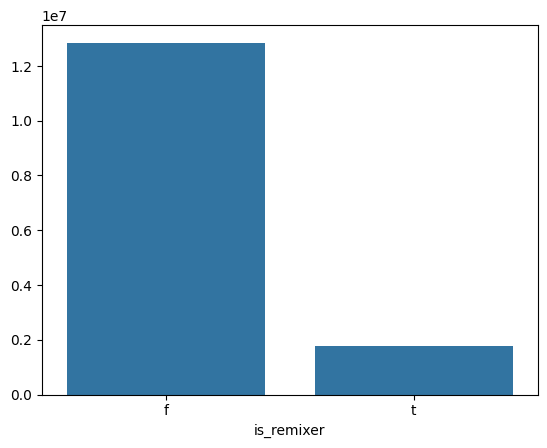

In [23]:
Q1 = bp_artist_track['is_remixer'].value_counts()
sns.barplot(x=Q1.index, y=Q1.values)

<Axes: xlabel='song_count', ylabel='genre_name'>

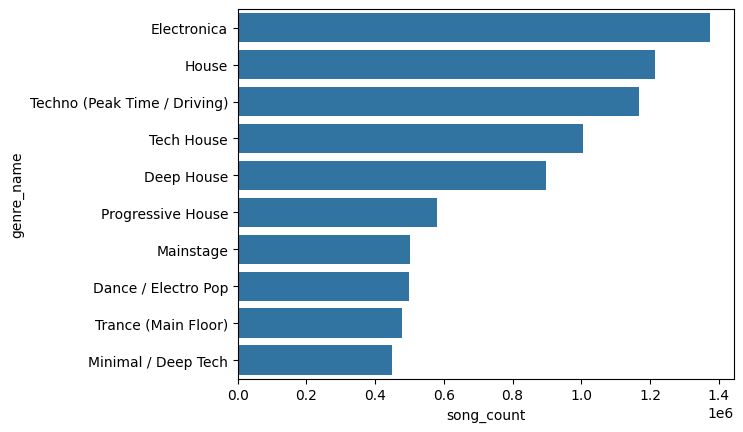

In [24]:
Q2 = pd.DataFrame()
Q2['genre_name'] = bp_genre['genre_name']
Q2['song_count'] = bp_genre['song_count']
Q2 = Q2.sort_values(by='song_count', ascending=False).head(10)

sns.barplot(y=Q2['genre_name'], x=Q2['song_count'])

In [25]:
Q3 = pd.merge(bp_artist, bp_artist_track, on='artist_id', how='inner')

<Axes: ylabel='artist_name'>

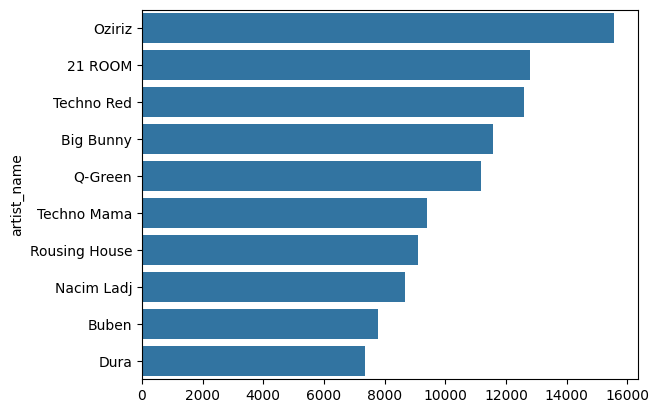

In [26]:
artist_counts = Q3['artist_name'].value_counts().head(10)
sns.barplot(y=artist_counts.index, x=artist_counts.values)

In [27]:
Q4 = pd.merge(bp_track, bp_label, on='label_id', how='inner')

<Axes: ylabel='label_name'>

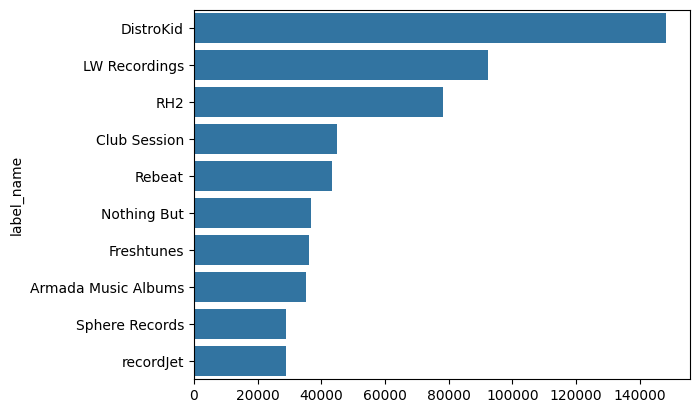

In [28]:
label_counts = Q4['label_name'].value_counts().head(10)
sns.barplot(y=label_counts.index, x=label_counts.values)


<Axes: xlabel='bpm', ylabel='Density'>

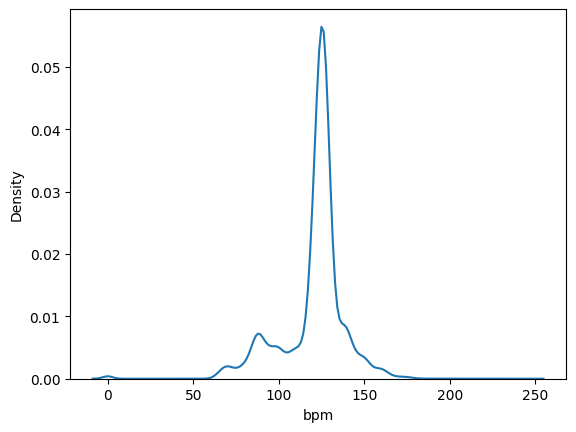

In [29]:
# Sample the data (use 10,000 points for example)
sampled_data = bp_track['bpm'].sample(10000, random_state=42)

# Plot the KDE with adjustments
sns.kdeplot(data=sampled_data)

<Axes: xlabel='duration_ms', ylabel='Density'>

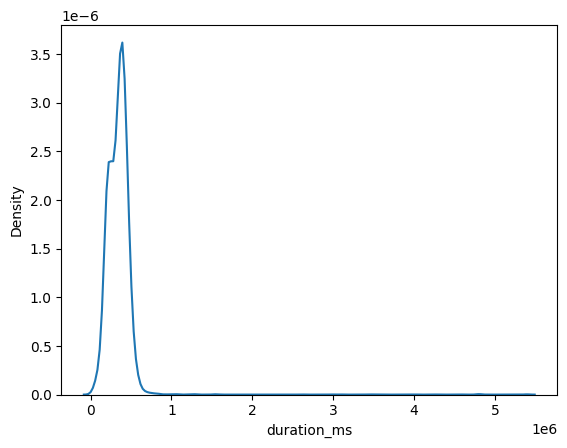

In [30]:
# Sample the data (use 10,000 points for example)
sampled_data = bp_track['duration_ms'].sample(10000, random_state=42)

# Plot the KDE with adjustments
sns.kdeplot(data=sampled_data)

<Axes: ylabel='key_name'>

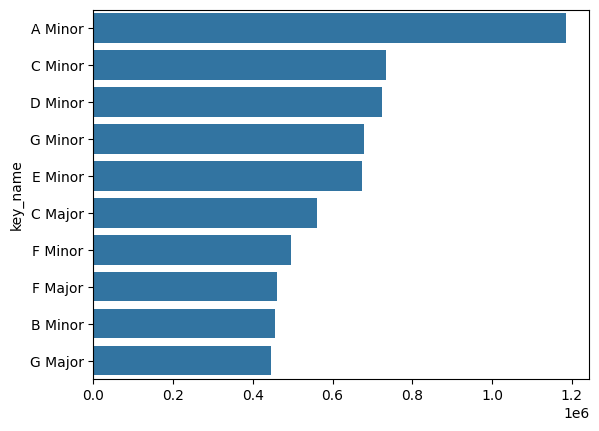

In [31]:
# Merge the DataFrames on 'key_id'
Q5 = pd.merge(bp_track, bp_key, on='key_id', how='inner')

# Count the occurrences of 'key_name'
key_counts = Q5['key_name'].value_counts().head(10)

# Plot the data using seaborn
sns.barplot(y=key_counts.index, x=key_counts.values)

In [32]:
bp_inferential = pd.merge(bp_track, bp_genre[['genre_id', 'genre_name']], on='genre_id', how='inner')

In [33]:
bp_inferential.drop('genre_id', axis=1, inplace=True)

In [34]:
bp_inferential

,track_id,title,mix,is_remixed,release_date,subgenre_id,bpm,duration,duration_ms,isrc,key_id,label_id,release_id,genre_name
0,17775434,Navigator 3000,Original Mix,f,2023-06-09,266.0,130,6:48,408830.0,DECY62300081,23.0,3222,4144460,Trance (Raw / Deep / Hypnotic)
1,17610335,Nehorah,Original Mix,f,2023-06-05,265.0,124,6:47,407439.0,GBCDK2303028,15.0,258,4091230,Trance (Raw / Deep / Hypnotic)
2,17610338,Akawi,Original Mix,f,2023-06-05,265.0,124,7:17,437066.0,GBCDK2303029,22.0,258,4091230,Trance (Raw / Deep / Hypnotic)
3,17658499,Interplanetary Species,Original Mix,f,2023-06-05,265.0,93,6:27,387096.0,DELK12300089,24.0,68438,4106998,Trance (Raw / Deep / Hypnotic)
4,17658498,Echoing Planetary Motion,Original Mix,f,2023-06-05,265.0,125,7:40,460800.0,DELK12300088,20.0,68438,4106998,Trance (Raw / Deep / Hypnotic)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10685326,227222,I Promise feat. Syndicate 305,Nu Disco Version,f,1991-12-06,NaN,123,5:39,339622.0,CAH250630480,33.0,3677,41353,Deep House
10685327,15597068,Illusion,Original Mix,f,1991-06-01,NaN,117,6:19,379625.0,ITR831590004,19.0,30680,3475657,Deep House
10685328,228488,The Spirit feat. Syndicate,Haunted Dub,f,1991-01-10,NaN,122,5:20,320735.0,CAH250630520,22.0,3677,41623,Deep House
10685329,228492,The Spirit feat. Syndicate,Evil Dub,f,1991-01-10,NaN,118,5:29,329777.0,CAH250630540,20.0,3677,41623,Deep House


In [35]:
bp_inferential.drop(columns=['track_id', 'title', 'mix', 'is_remixed', 'release_date', 'subgenre_id', 'duration', 'isrc', 'key_id', 'label_id', 'release_id'], inplace=True, axis=1)

In [36]:
bp_inferential.isnull().sum()

bpm               0
duration_ms    2632
genre_name        0
dtype: int64

In [37]:
bp_inferential.dropna(inplace=True)

ANOVA test for BPM: F-statistic = 52203.461281039265, p-value = 0.0
ANOVA test for Duration: F-statistic = 30524.40228837868, p-value = 0.0


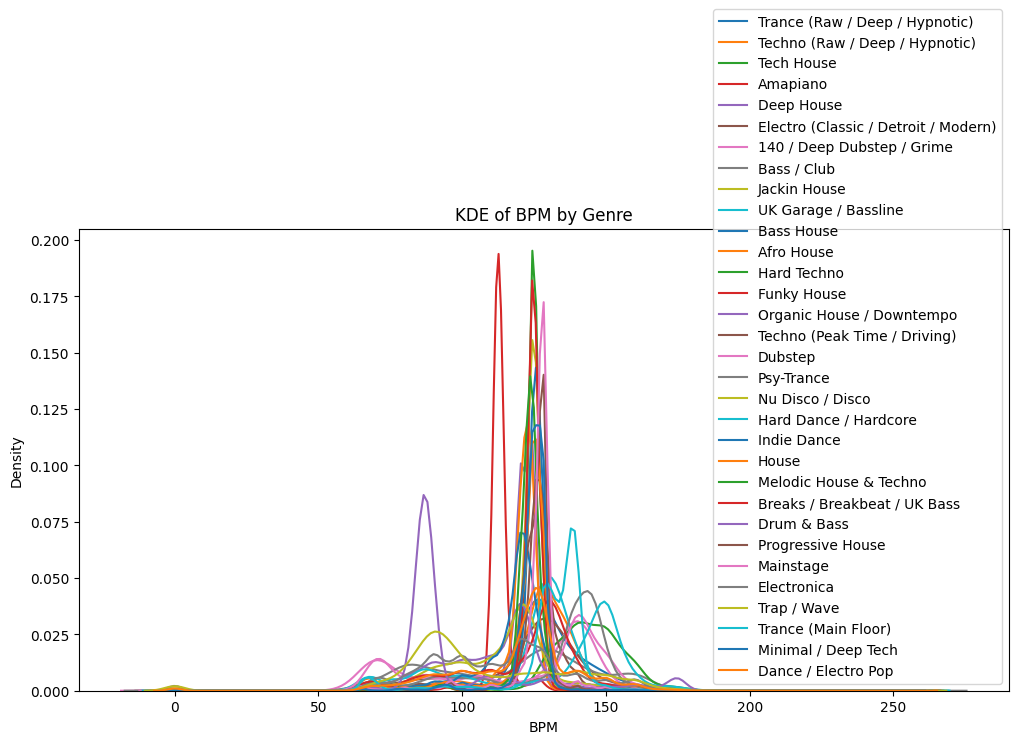

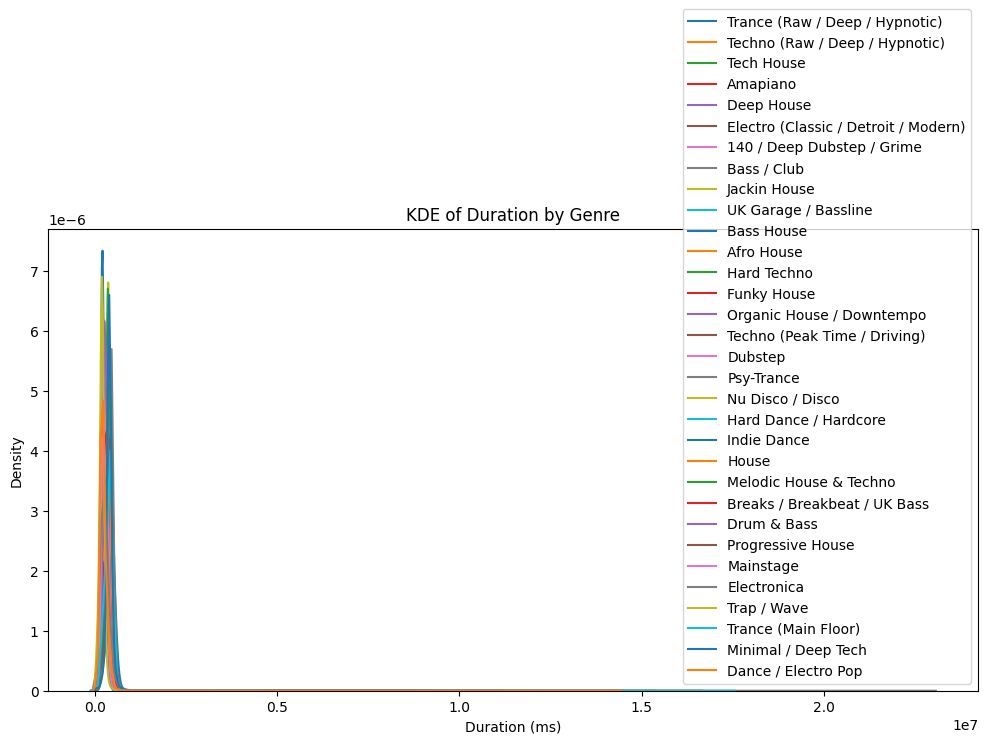

In [38]:
# Group by 'genre_name' and calculate the mean BPM and mean duration
genre_grouped = bp_inferential.groupby('genre_name').agg({'bpm': 'mean', 'duration_ms': 'mean'}).reset_index()

# Perform ANOVA test for BPM
bpm_anova = stats.f_oneway(*[bp_inferential[bp_inferential['genre_name'] == genre]['bpm'] for genre in bp_inferential['genre_name'].unique()])
print(f'ANOVA test for BPM: F-statistic = {bpm_anova.statistic}, p-value = {bpm_anova.pvalue}')

# Perform ANOVA test for duration_ms
duration_anova = stats.f_oneway(*[bp_inferential[bp_inferential['genre_name'] == genre]['duration_ms'] for genre in bp_inferential['genre_name'].unique()])
print(f'ANOVA test for Duration: F-statistic = {duration_anova.statistic}, p-value = {duration_anova.pvalue}')

# Plot KDEs for BPM
plt.figure(figsize=(12, 6))
for genre in bp_inferential['genre_name'].unique():
    subset = bp_inferential[bp_inferential['genre_name'] == genre]
    sns.kdeplot(subset['bpm'], label=genre, bw_adjust=1.5)
plt.xlabel('BPM')
plt.ylabel('Density')
plt.title('KDE of BPM by Genre')
plt.legend()
plt.show()

# Plot KDEs for Duration
plt.figure(figsize=(12, 6))
for genre in bp_inferential['genre_name'].unique():
    subset = bp_inferential[bp_inferential['genre_name'] == genre]
    sns.kdeplot(subset['duration_ms'], label=genre, bw_adjust=1.5)
plt.xlabel('Duration (ms)')
plt.ylabel('Density')
plt.title('KDE of Duration by Genre')
plt.legend()
plt.show()


In [39]:
track_id_to_search = 4993057

# Perform the search for the exact track_id (no need for contains or case-sensitive search)
search_result = bp_track[bp_track['track_id'] == track_id_to_search]

search_result


,track_id,title,mix,is_remixed,release_date,genre_id,subgenre_id,bpm,duration,duration_ms,isrc,key_id,label_id,release_id
2376992,4993057,Booyah feat. We Are Loud feat. Sonny Wilson,Original Mix,f,2013-12-09,96,245.0,128,5:11,311211.0,NLDD61300077,2.0,15769,1211902


In [40]:
track_id_to_search = 5581162

# Perform the search for the exact track_id (no need for contains or case-sensitive search)
search_result = bp_track[bp_track['track_id'] == track_id_to_search]

search_result

,track_id,title,mix,is_remixed,release_date,genre_id,subgenre_id,bpm,duration,duration_ms,isrc,key_id,label_id,release_id
8607830,5581162,Sandstorm,Original Club Mix,f,2014-07-25,7,NaN,136,7:23,443988.0,GBDRY0000002,9.0,38,1334452


In [41]:
bp_artist.head(2)

,artist_id,artist_name
0,31526,Tromesa
1,943790,Magik (UK)


In [42]:
bp_track.head(2)

,track_id,title,mix,is_remixed,release_date,genre_id,subgenre_id,bpm,duration,duration_ms,isrc,key_id,label_id,release_id
0,17775434,Navigator 3000,Original Mix,f,2023-06-09,99,266.0,130,6:48,408830.0,DECY62300081,23.0,3222,4144460
1,17610335,Nehorah,Original Mix,f,2023-06-05,99,265.0,124,6:47,407439.0,GBCDK2303028,15.0,258,4091230


In [43]:
bp_artist_track.head(2)

,artist_id,track_id,updated_on,is_remixer
0,31526,17767172,2023-09-14 16:19:56,f
1,943790,17767172,2023-09-14 16:19:56,f


In [46]:
# Step 1: Merge bp_artist_track with bp_artist to get artist_name
merged_artist = pd.merge(bp_artist_track, bp_artist, on='artist_id', how='left')

# Step 2: Merge the result with bp_track to get the track details and title
merged_data = pd.merge(merged_artist, bp_track, on='track_id', how='left')

# Step 3: Group by 'track_id' and concatenate artist names, ensuring artist_name is a string and handling NaN values
merged_data_grouped = merged_data.groupby('track_id').agg({
    'title': 'first',  # Get the first occurrence of the title (it's the same for all rows)
    'artist_name': lambda x: ', '.join(x.fillna('').astype(str))  # Convert artist_name to string, handle NaN values
}).reset_index()

# Step 4: Create the 'song' column as 'title by artist_name'
merged_data_grouped['song'] = merged_data_grouped['title'] + ' by ' + merged_data_grouped['artist_name']

# Step 5: Create bp_song DataFrame with just 'track_id' and 'song'
bp_song = merged_data_grouped[['track_id', 'song']]

# Display the resulting DataFrame
bp_song.head()

,track_id,song
0,4971,Beatfreaker by Steve Smooth
1,4972,Beatfreaker by Steve Smooth
2,4973,Drop It by Steve Smooth
3,4974,Tranzmission by Hatiras
4,4975,Starz by Hatiras


In [48]:
track_id_to_search = 5581162

# Perform the search for the exact track_id (no need for contains or case-sensitive search)
search_result = bp_song[bp_song['track_id'] == track_id_to_search]

search_result

,track_id,song
2576745,5581162,Sandstorm by Darude


In [49]:
bp_song.to_csv('data/bp_song.csv', index=False)